In [29]:
import pandas as pd

# 读取两个CSV文件
csv1 = pd.read_csv('/media/amers/SSD_part1/whx/ResNet_forDPC/dpc_retrieval_results_withprior3.csv')
csv2 = pd.read_csv('/media/amers/SSD_part1/whx/ResNet_forDPC/DPC_Aeronet_2025_withPrior.csv')

# 直接按列合并（假设顺序完全一致）
csv1[['AOD_550nm', 'SSA_550nm','Pred_AOD_550nm', 'Pred_SSA_550nm']] = csv2[['AOD_550nm', 'SSA_550nm','Pred_AOD_550nm', 'Pred_SSA_550nm']]

# 保存结果
csv1.to_csv('csv1_merged_withprior3.csv', index=False)

print(f"合并完成！")
print(f"最终形状: {csv1.shape}")
print(f"结果已保存到: csv1_merged_withprior3.csv")

合并完成！
最终形状: (2022, 33)
结果已保存到: csv1_merged_withprior3.csv


In [2]:
import pandas as pd

# 读取上一步合并好的文件和目标站点文件
csv1_merged = pd.read_csv('csv1_merged_withprior_9pixel.csv')
#csv3 = pd.read_csv('/media/amers/SSD_part1/whx/ResNet_forDPC/beijing_test.csv')
csv3 = pd.read_csv('/media/amers/SSD_part1/whx/ResNet_forDPC/china_2025_1.5.csv')
#csv3 = pd.read_csv('/media/amers/SSD_part1/whx/ResNet_forDPC/beijing_test.csv')

# 获取csv3中的目标站点列表
target_sites = csv3['Site_Name'].unique()

# 只保留csv3中出现的站点
csv1_filtered = csv1_merged[csv1_merged['site_name'].isin(target_sites)]

print(f"过滤前形状: {csv1_merged.shape}")
print(f"过滤后形状: {csv1_filtered.shape}")
print(f"保留了 {len(csv1_filtered)} 行数据")
print(f"去除了 {len(csv1_merged) - len(csv1_filtered)} 行数据")

# 保存最终结果
csv1_filtered.to_csv('csv1_merged_filtered_withprior_9pixel.csv', index=False)
print(f"\n最终结果已保存到: csv1_merged_filtered_withprior_9pixel.csv")

过滤前形状: (24426, 33)
过滤后形状: (5674, 33)
保留了 5674 行数据
去除了 18752 行数据

最终结果已保存到: csv1_merged_filtered_withprior_9pixel.csv


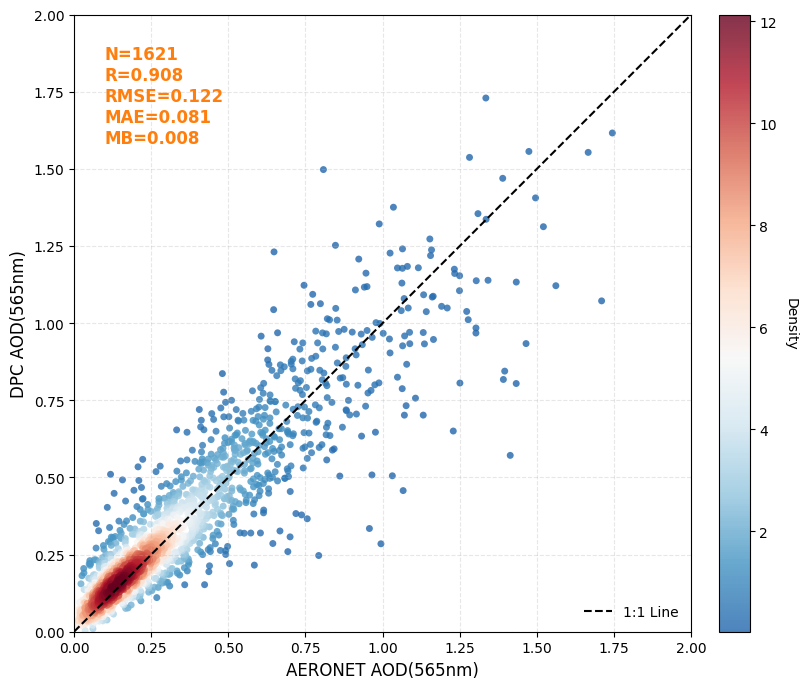

相关系数 R = 0.908
RMSE = 0.122
MAE = 0.081
平均偏差 MB = 0.008


In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy.stats import gaussian_kde

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# ==================== 数据读取部分（替换为你的路径）====================
df = pd.read_csv('/media/amers/SSD_part1/whx/ResNet_forDPC/csv1_merged_withprior3.csv')
df = df[df['AOD'] > 0]
df = df[df['AOD_550nm'] > 0]
df = df[df['final_cost'] < 15]
x = df['AOD_550nm'].values
y = df['AOD'].values


# ==================== 绘图部分 ====================
# 计算统计指标
N = len(x)
R = np.corrcoef(x, y)[0, 1]
RMSE = np.sqrt(np.mean((y - x)**2))
MAE = np.mean(np.abs(y - x))
MB = np.mean(y - x)

# 创建图形
fig, ax = plt.subplots(figsize=(8, 7))

# 计算密度用于颜色映射
xy = np.vstack([x, y])
z = gaussian_kde(xy)(xy)

# 按密度排序，确保高密度点在上方
idx = z.argsort()
x_sorted, y_sorted, z_sorted = x[idx], y[idx], z[idx]

# 创建自定义颜色映射（从蓝到红，类似参考图）
colors = ['#2166ac', '#4393c3', '#92c5de', '#d1e5f0', '#f7f7f7', 
          '#fddbc7', '#f4a582', '#d6604d', '#b2182b', '#67001f']
cmap = LinearSegmentedColormap.from_list('custom', colors)

# 绘制密度散点图
scatter = ax.scatter(x_sorted, y_sorted, c=z_sorted, s=25, cmap=cmap, 
                     alpha=0.8, edgecolors='none')

# 添加1:1线
ax.plot([0, 2], [0, 2], 'k--', linewidth=1.5, label='1:1 Line')

# 设置坐标轴
ax.set_xlim(0, 2)  # 根据你的数据范围调整，参考图是0-0.5
ax.set_ylim(0, 2)
ax.set_xlabel('AERONET AOD(565nm)', fontsize=12)
ax.set_ylabel('DPC AOD(565nm)', fontsize=12)

# 添加统计信息文本（左上角，橙色）
stats_text = f'N={N}\nR={R:.3f}\nRMSE={RMSE:.3f}\nMAE={MAE:.3f}\nMB={MB:.3f}'
ax.text(0.05, 0.95, stats_text, transform=ax.transAxes, fontsize=12,
        verticalalignment='top', color='#ff7f0e', fontweight='bold')

# 添加颜色条（右侧）
cbar = plt.colorbar(scatter, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Density', rotation=270, labelpad=15)

# 添加图例
ax.legend(loc='lower right', frameon=False)

# 设置等比例
ax.set_aspect('equal')

# 添加网格线（可选）
ax.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

# 打印统计信息
print(f'相关系数 R = {R:.3f}')
print(f'RMSE = {RMSE:.3f}')
print(f'MAE = {MAE:.3f}')
print(f'平均偏差 MB = {MB:.3f}')

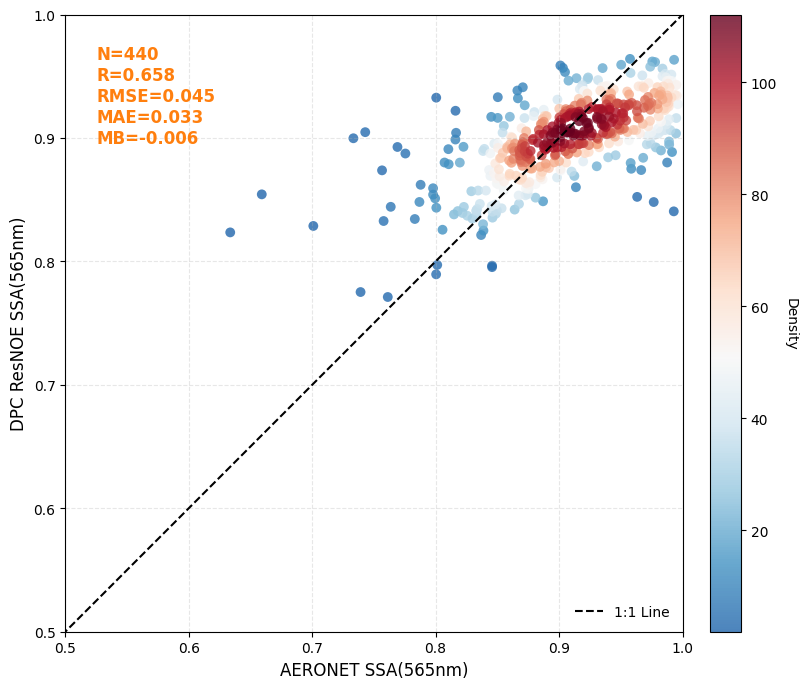

相关系数 R = 0.658
RMSE = 0.045
MAE = 0.033
平均偏差 MB = -0.006


In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy.stats import gaussian_kde

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# ==================== 数据读取部分（替换为你的路径）====================
df = pd.read_csv('/media/amers/SSD_part1/whx/ResNet_forDPC/csv1_merged_withprior3.csv')
df = df[df['AOD'] > 0]
df = df[df['AOD_550nm'] > 0]
df = df[df['SSA'] > 0.6]
df = df[df['SSA_550nm'] >0.6]

df = df[df['final_cost'] < 10]
x = df['SSA_550nm'].values
y = df['SSA'].values
#y = df['Pred_SSA_550nm'].values


# ==================== 绘图部分 ====================
# 计算统计指标
N = len(x)
R = np.corrcoef(x, y)[0, 1]
RMSE = np.sqrt(np.mean((y - x)**2))
MAE = np.mean(np.abs(y - x))
MB = np.mean(y - x)

# 创建图形
fig, ax = plt.subplots(figsize=(8, 7))

# 计算密度用于颜色映射
xy = np.vstack([x, y])
z = gaussian_kde(xy)(xy)

# 按密度排序，确保高密度点在上方
idx = z.argsort()
x_sorted, y_sorted, z_sorted = x[idx], y[idx], z[idx]

# 创建自定义颜色映射（从蓝到红，类似参考图）
colors = ['#2166ac', '#4393c3', '#92c5de', '#d1e5f0', '#f7f7f7', 
          '#fddbc7', '#f4a582', '#d6604d', '#b2182b', '#67001f']
cmap = LinearSegmentedColormap.from_list('custom', colors)

# 绘制密度散点图
scatter = ax.scatter(x_sorted, y_sorted, c=z_sorted, s=50, cmap=cmap, 
                     alpha=0.8, edgecolors='none')

# 添加1:1线
ax.plot([0, 2], [0, 2], 'k--', linewidth=1.5, label='1:1 Line')

# 设置坐标轴
ax.set_xlim(0.5, 1)  # 根据你的数据范围调整，参考图是0-0.5
ax.set_ylim(0.5, 1)
ax.set_xlabel('AERONET SSA(565nm)', fontsize=12)
ax.set_ylabel('DPC ResNOE SSA(565nm)', fontsize=12)

# 添加统计信息文本（左上角，橙色）
stats_text = f'N={N}\nR={R:.3f}\nRMSE={RMSE:.3f}\nMAE={MAE:.3f}\nMB={MB:.3f}'
ax.text(0.05, 0.95, stats_text, transform=ax.transAxes, fontsize=12,
        verticalalignment='top', color='#ff7f0e', fontweight='bold')

# 添加颜色条（右侧）
cbar = plt.colorbar(scatter, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Density', rotation=270, labelpad=15)

# 添加图例
ax.legend(loc='lower right', frameon=False)

# 设置等比例
ax.set_aspect('equal')

# 添加网格线（可选）
ax.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

# 打印统计信息
print(f'相关系数 R = {R:.3f}')
print(f'RMSE = {RMSE:.3f}')
print(f'MAE = {MAE:.3f}')
print(f'平均偏差 MB = {MB:.3f}')

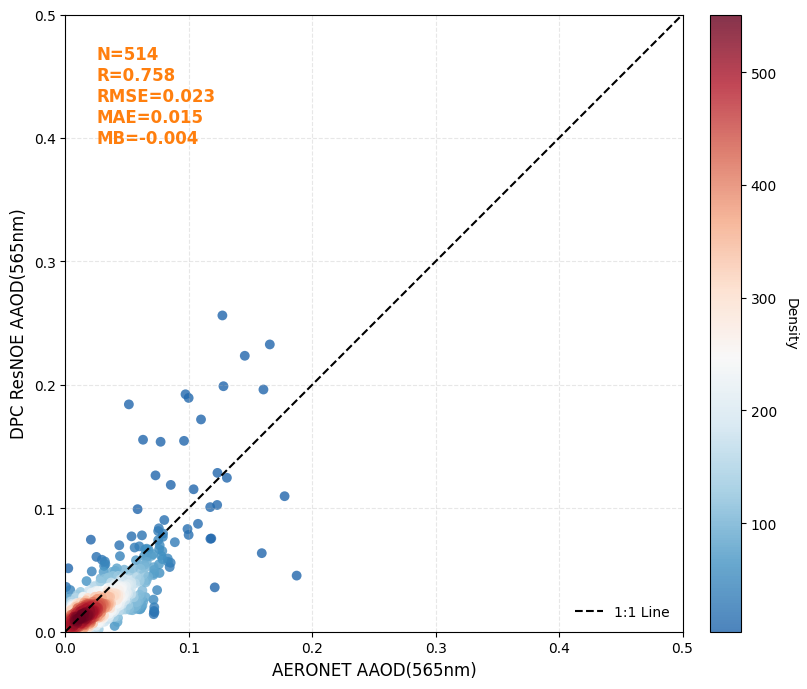

相关系数 R = 0.758
RMSE = 0.023
MAE = 0.015
平均偏差 MB = -0.004


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy.stats import gaussian_kde

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# ==================== 数据读取部分（替换为你的路径）====================
df = pd.read_csv('/media/amers/SSD_part1/whx/ResNet_forDPC/csv1_merged_withprior3.csv')
df = df[df['AOD'] > 0]
df = df[df['AOD_550nm'] > 0]
df = df[df['SSA'] > 0.6]
df = df[df['SSA_550nm'] >0.6]

df = df[df['final_cost'] < 10]
x = (1-df['SSA_550nm'].values)*df['AOD_550nm'].values
y = (1-df['SSA'].values)*df['AOD'].values
#y = df['Pred_SSA_550nm'].values


# ==================== 绘图部分 ====================
# 计算统计指标
N = len(x)
R = np.corrcoef(x, y)[0, 1]
RMSE = np.sqrt(np.mean((y - x)**2))
MAE = np.mean(np.abs(y - x))
MB = np.mean(y - x)

# 创建图形
fig, ax = plt.subplots(figsize=(8, 7))

# 计算密度用于颜色映射
xy = np.vstack([x, y])
z = gaussian_kde(xy)(xy)

# 按密度排序，确保高密度点在上方
idx = z.argsort()
x_sorted, y_sorted, z_sorted = x[idx], y[idx], z[idx]

# 创建自定义颜色映射（从蓝到红，类似参考图）
colors = ['#2166ac', '#4393c3', '#92c5de', '#d1e5f0', '#f7f7f7', 
          '#fddbc7', '#f4a582', '#d6604d', '#b2182b', '#67001f']
cmap = LinearSegmentedColormap.from_list('custom', colors)

# 绘制密度散点图
scatter = ax.scatter(x_sorted, y_sorted, c=z_sorted, s=50, cmap=cmap, 
                     alpha=0.8, edgecolors='none')

# 添加1:1线
ax.plot([0, 2], [0, 2], 'k--', linewidth=1.5, label='1:1 Line')

# 设置坐标轴
ax.set_xlim(0, 0.5)  # 根据你的数据范围调整，参考图是0-0.5
ax.set_ylim(0, 0.5)
ax.set_xlabel('AERONET AAOD(565nm)', fontsize=12)
ax.set_ylabel('DPC ResNOE AAOD(565nm)', fontsize=12)

# 添加统计信息文本（左上角，橙色）
stats_text = f'N={N}\nR={R:.3f}\nRMSE={RMSE:.3f}\nMAE={MAE:.3f}\nMB={MB:.3f}'
ax.text(0.05, 0.95, stats_text, transform=ax.transAxes, fontsize=12,
        verticalalignment='top', color='#ff7f0e', fontweight='bold')

# 添加颜色条（右侧）
cbar = plt.colorbar(scatter, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Density', rotation=270, labelpad=15)

# 添加图例
ax.legend(loc='lower right', frameon=False)

# 设置等比例
ax.set_aspect('equal')

# 添加网格线（可选）
ax.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

# 打印统计信息
print(f'相关系数 R = {R:.3f}')
print(f'RMSE = {RMSE:.3f}')
print(f'MAE = {MAE:.3f}')
print(f'平均偏差 MB = {MB:.3f}')

###  FMF 与 RIN匹配

In [34]:
import os
import pandas as pd
import numpy as np
from datetime import timedelta
from tqdm import tqdm
import glob
import warnings

warnings.filterwarnings('ignore')

# ==============================================================================
# 1. 数学插值函数
# ==============================================================================
def interp_log(val_440, val_675):
    """ 对数插值 (适用于 AOD, Fine AOD, Coarse AOD) """
    if pd.isna(val_440) or pd.isna(val_675) or val_440 == -999.0 or val_675 == -999.0:
        return np.nan
    # 如果遇到极小值(<=0)，对数无意义，回退到线性插值
    if val_440 <= 0 or val_675 <= 0:
        return interp_lin(val_440, val_675)
    
    angstrom = -np.log(val_440 / val_675) / np.log(440.0 / 675.0)
    return val_440 * ((565.0 / 440.0) ** (-angstrom))

def interp_lin(val_440, val_675):
    """ 线性插值 (适用于 MR, MI, SSA) """
    if pd.isna(val_440) or pd.isna(val_675) or val_440 == -999.0 or val_675 == -999.0:
        return np.nan
    slope = (val_675 - val_440) / (675.0 - 440.0)
    return val_440 + slope * (565.0 - 440.0)

# ==============================================================================
# 2. AERONET 文件读取与预加载
# ==============================================================================
def read_aeronet_file(filepath):
    """ 智能跳过头部说明，读取 AERONET 数据 """
    try:
        skip_row = 0
        with open(filepath, 'r', encoding='utf-8', errors='ignore') as f:
            for i, line in enumerate(f):
                if line.startswith('Date(') or line.startswith('AERONET_Site') or line.startswith('Site'):
                    skip_row = i
                    break
        df = pd.read_csv(filepath, skiprows=skip_row, na_values=[-999.0, -999])
        if 'Date(dd:mm:yyyy)' not in df.columns: return None
        
        df.dropna(subset=['Date(dd:mm:yyyy)', 'Time(hh:mm:ss)'], inplace=True)
        df['datetime'] = pd.to_datetime(df['Date(dd:mm:yyyy)'] + ' ' + df['Time(hh:mm:ss)'], format='%d:%m:%Y %H:%M:%S')
        return df
    except: return None

def preload_aeronet_folder(folder_path):
    """ 遍历文件夹，将所有站点的 DataFrame 存入字典，键为 site_name """
    data_dict = {}
    if not os.path.exists(folder_path): return data_dict
    
    files = glob.glob(os.path.join(folder_path, "*.*"))
    print(f"正在预加载目录 {folder_path}，找到 {len(files)} 个文件...")
    
    for f in tqdm(files, desc="加载 AERONET", leave=False):
        df = read_aeronet_file(f)
        if df is not None and not df.empty:
            # 智能获取站点名列
            site_col = 'AERONET_Site' if 'AERONET_Site' in df.columns else 'Site'
            if site_col in df.columns:
                site_name = df[site_col].iloc[0]
                data_dict[site_name] = df
    return data_dict

# ==============================================================================
# 3. 主匹配逻辑
# ==============================================================================
def match_all_truths(retrieval_csv, fmf_dir, rin_dir, output_csv):
    print(f"\n 读取反演结果: {retrieval_csv}")
    df_ret = pd.read_csv(retrieval_csv)
    
    # 确定时间列名 (兼容 'time' 或 'sat_time_utc' 或 'match_datetime')
    time_col = 'time'
        
    df_ret[time_col] = pd.to_datetime(df_ret[time_col],format='mixed')
    
    # 初始化新列
    new_cols = ['Aeronet_FineAOD_565nm', 'Aeronet_CoarseAOD_565nm', 'Aeronet_MR_565nm', 'Aeronet_MI_565nm']
    for col in new_cols: df_ret[col] = np.nan

    # 预加载数据到内存 (极大地提升匹配速度)
    print("\n 阶段 1: 预加载 FMF 数据")
    fmf_data = preload_aeronet_folder(fmf_dir)
    print("\n 阶段 2: 预加载 RIN 数据")
    rin_data = preload_aeronet_folder(rin_dir)

    print(f"\n⏳ 阶段 3: 开始时空匹配 (总记录数: {len(df_ret)})...")
    
    fmf_matched = 0
    rin_matched = 0

    for idx, row in tqdm(df_ret.iterrows(), total=len(df_ret), desc="匹配中"):
        site = row['site_name']
        sat_time = row[time_col]

        # ---------------------------------------------------------
        # 匹配 FMF (Fine/Coarse AOD) - 时间窗口 ±60 分钟
        # ---------------------------------------------------------
        if site in fmf_data:
            df_fmf = fmf_data[site]
            mask = (df_fmf['datetime'] >= sat_time - timedelta(minutes=60)) & \
                   (df_fmf['datetime'] <= sat_time + timedelta(minutes=60))
            matched_fmf = df_fmf[mask]
            
            if not matched_fmf.empty:
                # 动态寻找列名
                fine_440 = [c for c in matched_fmf.columns if 'Fine' in c and '440' in c]
                fine_675 = [c for c in matched_fmf.columns if 'Fine' in c and '675' in c]
                coarse_440 = [c for c in matched_fmf.columns if 'Coarse' in c and '440' in c]
                coarse_675 = [c for c in matched_fmf.columns if 'Coarse' in c and '675' in c]
                
                if fine_440 and fine_675 and coarse_440 and coarse_675:
                    f440_mean = matched_fmf[fine_440[0]].mean()
                    f675_mean = matched_fmf[fine_675[0]].mean()
                    c440_mean = matched_fmf[coarse_440[0]].mean()
                    c675_mean = matched_fmf[coarse_675[0]].mean()
                    
                    df_ret.at[idx, 'Aeronet_FineAOD_565nm'] = interp_log(f440_mean, f675_mean)
                    df_ret.at[idx, 'Aeronet_CoarseAOD_565nm'] = interp_log(c440_mean, c675_mean)
                    fmf_matched += 1

        # ---------------------------------------------------------
        # 匹配 RIN (MR/MI) - 时间窗口 ±120 分钟 (Inversion 较稀疏)
        # ---------------------------------------------------------
        if site in rin_data:
            df_rin = rin_data[site]
            mask = (df_rin['datetime'] >= sat_time - timedelta(minutes=120)) & \
                   (df_rin['datetime'] <= sat_time + timedelta(minutes=120))
            matched_rin = df_rin[mask]
            
            if not matched_rin.empty:
                # 动态寻找列名
                mr_440 = [c for c in matched_rin.columns if 'Real_Part' in c and '440' in c]
                mr_675 = [c for c in matched_rin.columns if 'Real_Part' in c and '675' in c]
                mi_440 = [c for c in matched_rin.columns if 'Imaginary_Part' in c and '440' in c]
                mi_675 = [c for c in matched_rin.columns if 'Imaginary_Part' in c and '675' in c]
                
                if mr_440 and mr_675 and mi_440 and mi_675:
                    mr440_mean = matched_rin[mr_440[0]].mean()
                    mr675_mean = matched_rin[mr_675[0]].mean()
                    mi440_mean = matched_rin[mi_440[0]].mean()
                    mi675_mean = matched_rin[mi_675[0]].mean()
                    
                    df_ret.at[idx, 'Aeronet_MR_565nm'] = interp_lin(mr440_mean, mr675_mean)
                    df_ret.at[idx, 'Aeronet_MI_565nm'] = interp_lin(mi440_mean, mi675_mean)
                    rin_matched += 1

    # ==============================================================================
    # 4. 保存结果
    # ==============================================================================
    os.makedirs(os.path.dirname(output_csv), exist_ok=True)
    df_ret.to_csv(output_csv, index=False)
    
    print("\n" + "="*45)
    print(f" 所有真值匹配完成！")
    print(f"总反演记录数 : {len(df_ret)}")
    print(f"成功匹配 FMF : {fmf_matched} 条 (Fine/Coarse AOD)")
    print(f"成功匹配 RIN : {rin_matched} 条 (MR/MI)")
    print(f"结果已保存至 : {output_csv}")
    print("="*45)


if __name__ == "__main__":
    # 1. 你的反演结果 CSV (聚合后的或者原始的都可以)
    INPUT_RETRIEVAL_CSV = '/media/amers/SSD_part1/whx/ResNet_forDPC/csv1_merged_withprior3.csv'
    
    # 2. 存放 FMF 数据的文件夹 (包含 .aod 文件)
    FMF_DIR = '/media/amers/SSD_part1/aeronet_data/2025_FMF&RIN/L15/fmf/'
    
    # 3. 存放 RIN 数据的文件夹 (包含复折射指数文件)
    RIN_DIR = '/media/amers/SSD_part1/aeronet_data/2025_FMF&RIN/L15/rin/'
    
    # 4. 最终输出的 CSV 路径
    OUTPUT_CSV = '/media/amers/SSD_part1/whx/ResNet_forDPC/validation_Final_All.csv'
    
    match_all_truths(INPUT_RETRIEVAL_CSV, FMF_DIR, RIN_DIR, OUTPUT_CSV)


 读取反演结果: /media/amers/SSD_part1/whx/ResNet_forDPC/csv1_merged_withprior3.csv

 阶段 1: 预加载 FMF 数据
正在预加载目录 /media/amers/SSD_part1/aeronet_data/2025_FMF&RIN/L15/fmf/，找到 57 个文件...



 阶段 2: 预加载 RIN 数据
正在预加载目录 /media/amers/SSD_part1/aeronet_data/2025_FMF&RIN/L15/rin/，找到 57 个文件...



⏳ 阶段 3: 开始时空匹配 (总记录数: 2022)...


匹配中: 100%|██████████| 2022/2022 [00:01<00:00, 1059.09it/s]



 所有真值匹配完成！
总反演记录数 : 2022
成功匹配 FMF : 361 条 (Fine/Coarse AOD)
成功匹配 RIN : 761 条 (MR/MI)
结果已保存至 : /media/amers/SSD_part1/whx/ResNet_forDPC/validation_Final_All.csv


正在绘制 1/5: 细模态 AOD (Fine AOD)...


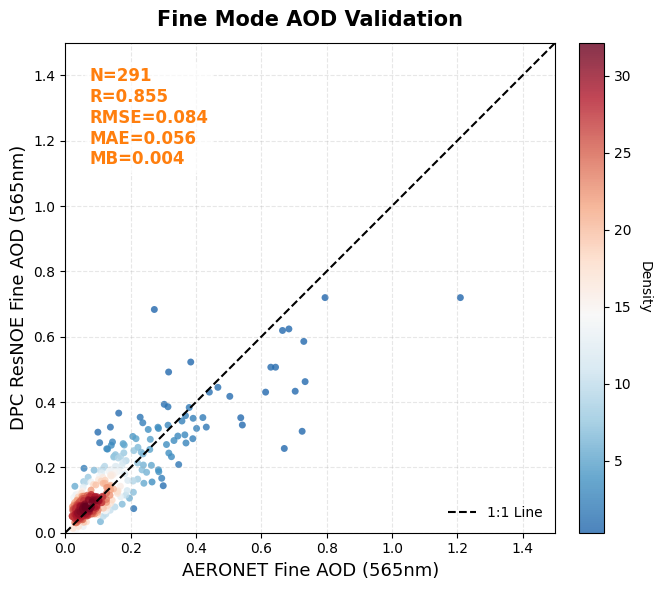

正在绘制 2/5: 粗模态 AOD (Coarse AOD)...


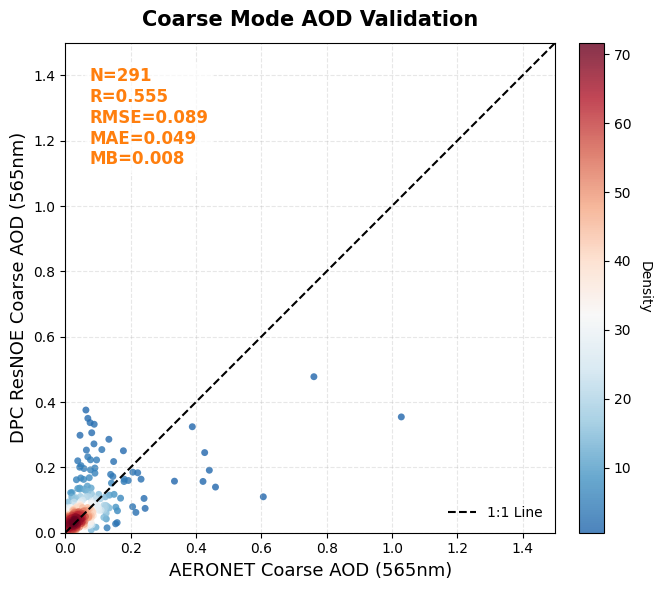

正在绘制 3/5: 细模态占比 (FMF)...


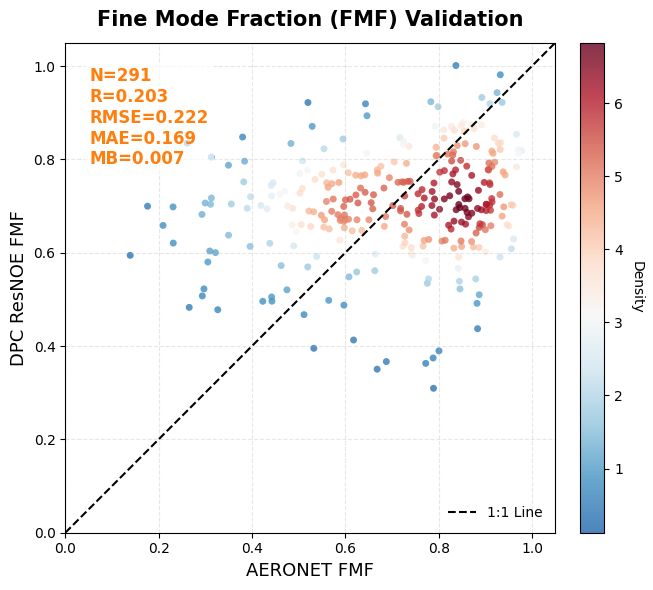

正在绘制 4/5: 复折射指数实部 (MR)...


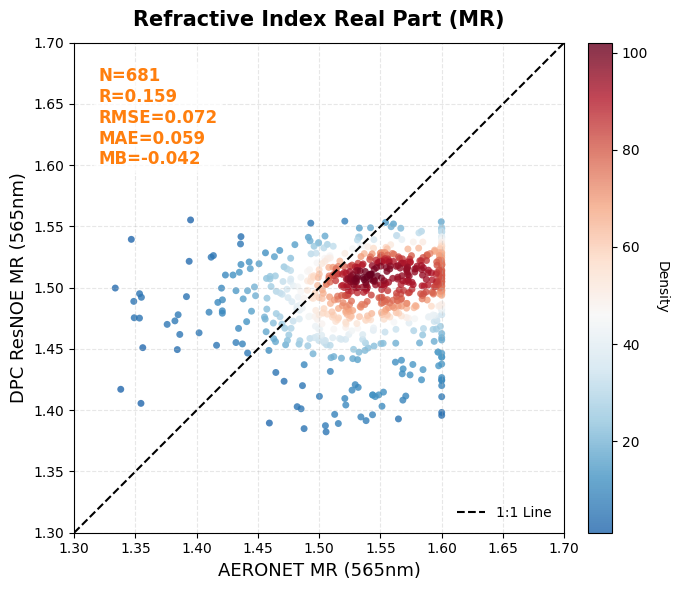

正在绘制 5/5: 复折射指数虚部 (MI)...


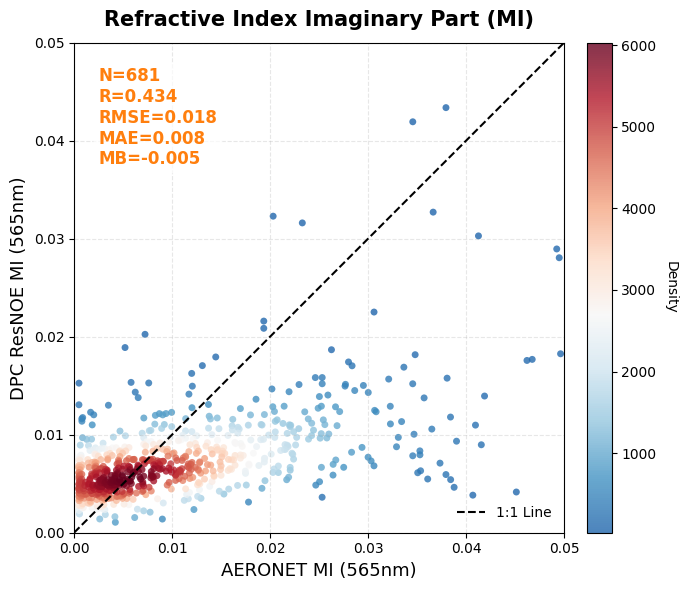

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy.stats import gaussian_kde
import warnings

warnings.filterwarnings('ignore')

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# ==================== 1. 数据读取与预处理 ====================
# 替换为你的实际路径
CSV_PATH = '/media/amers/SSD_part1/whx/ResNet_forDPC/validation_Final_All.csv'
df = pd.read_csv(CSV_PATH)

# 基础质量控制过滤
df = df[df['final_cost'] < 50]

# 计算 FMF (Fine Mode Fraction)
# 加上 1e-6 防止分母为 0
df['Aeronet_FMF'] = df['Aeronet_FineAOD_565nm'] / (df['Aeronet_FineAOD_565nm'] + df['Aeronet_CoarseAOD_565nm'] )
df['Ret_FMF'] = df['fineAOD'] / (df['fineAOD'] + df['coarseAOD'] )


# ==================== 2. 定义通用绘图函数 ====================
def plot_single_validation(df_data, col_x, col_y, xlabel, ylabel, limits, title):
    """
    独立绘制单张 KDE 密度验证图
    """
    # 提取数据并剔除 NaN 和无穷大的无效值
    temp_df = df_data[[col_x, col_y]].replace([np.inf, -np.inf], np.nan).dropna()
    
    # 如果数据量太少，跳过绘图
    if len(temp_df) < 5:
        print(f"⚠️ {title} 有效数据点不足，跳过绘图。")
        return

    x = temp_df[col_x].values
    y = temp_df[col_y].values

    # 计算统计指标
    N = len(x)
    R = np.corrcoef(x, y)[0, 1]
    RMSE = np.sqrt(np.mean((y - x)**2))
    MAE = np.mean(np.abs(y - x))
    MB = np.mean(y - x)

    # 创建图形
    fig, ax = plt.subplots(figsize=(7, 6))

    # 计算密度用于颜色映射
    xy = np.vstack([x, y])
    # 如果数据点完全一样会导致奇异矩阵，加一点点极小噪声保护
    try:
        z = gaussian_kde(xy)(xy)
    except np.linalg.LinAlgError:
        z = np.ones_like(x)

    # 按密度排序，确保高密度点在上方
    idx = z.argsort()
    x_sorted, y_sorted, z_sorted = x[idx], y[idx], z[idx]

    # 创建自定义颜色映射（从蓝到红）
    colors = ['#2166ac', '#4393c3', '#92c5de', '#d1e5f0', '#f7f7f7', 
              '#fddbc7', '#f4a582', '#d6604d', '#b2182b', '#67001f']
    cmap = LinearSegmentedColormap.from_list('custom', colors)

    # 绘制密度散点图
    scatter = ax.scatter(x_sorted, y_sorted, c=z_sorted, s=25, cmap=cmap, 
                         alpha=0.8, edgecolors='none')

    # 添加1:1线
    ax.plot([limits[0], limits[1]], [limits[0], limits[1]], 'k--', linewidth=1.5, label='1:1 Line')

    # 设置坐标轴
    ax.set_xlim(limits[0], limits[1])
    ax.set_ylim(limits[0], limits[1])
    ax.set_xlabel(xlabel, fontsize=13)
    ax.set_ylabel(ylabel, fontsize=13)
    ax.set_title(title, fontsize=15, fontweight='bold', pad=12)

    # 添加统计信息文本（左上角，橙色）
    stats_text = f'N={N}\nR={R:.3f}\nRMSE={RMSE:.3f}\nMAE={MAE:.3f}\nMB={MB:.3f}'
    ax.text(0.05, 0.95, stats_text, transform=ax.transAxes, fontsize=12,
            verticalalignment='top', color='#ff7f0e', fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7, edgecolor='none'))

    # 添加颜色条（右侧）
    cbar = plt.colorbar(scatter, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label('Density', rotation=270, labelpad=15)

    # 添加图例
    ax.legend(loc='lower right', frameon=False)

    # 设置等比例
    ax.set_aspect('equal')

    # 添加网格线
    ax.grid(True, linestyle='--', alpha=0.3)

    plt.tight_layout()
    
    # 如果想自动保存图片，取消下面这行的注释
    # plt.savefig(f"{title.replace(' ', '_')}.png", dpi=300)
    
    plt.show()

# ==================== 3. 依次调用函数绘制 5 张图 ====================

print("正在绘制 1/5: 细模态 AOD (Fine AOD)...")
plot_single_validation(
    df_data=df, 
    col_x='Aeronet_FineAOD_565nm', 
    col_y='fineAOD', 
    xlabel='AERONET Fine AOD (565nm)', 
    ylabel='DPC ResNOE Fine AOD (565nm)', 
    limits=[0, 1.5],  # 细模态范围通常在 0-1.5
    title='Fine Mode AOD Validation'
)

print("正在绘制 2/5: 粗模态 AOD (Coarse AOD)...")
plot_single_validation(
    df_data=df, 
    col_x='Aeronet_CoarseAOD_565nm', 
    col_y='coarseAOD', 
    xlabel='AERONET Coarse AOD (565nm)', 
    ylabel='DPC ResNOE Coarse AOD (565nm)', 
    limits=[0, 1.5],  # 粗模态范围
    title='Coarse Mode AOD Validation'
)

print("正在绘制 3/5: 细模态占比 (FMF)...")
plot_single_validation(
    df_data=df, 
    col_x='Aeronet_FMF', 
    col_y='Ret_FMF', 
    xlabel='AERONET FMF', 
    ylabel='DPC ResNOE FMF', 
    limits=[0, 1.05],  # FMF 是比例，严格在 0-1 之间
    title='Fine Mode Fraction (FMF) Validation'
)

print("正在绘制 4/5: 复折射指数实部 (MR)...")
plot_single_validation(
    df_data=df, 
    col_x='Aeronet_MR_565nm', 
    col_y='MR', 
    xlabel='AERONET MR (565nm)', 
    ylabel='DPC ResNOE MR (565nm)', 
    limits=[1.3, 1.7],  # MR 的物理范围通常在 1.3 到 1.7 之间
    title='Refractive Index Real Part (MR)'
)

print("正在绘制 5/5: 复折射指数虚部 (MI)...")
plot_single_validation(
    df_data=df, 
    col_x='Aeronet_MI_565nm', 
    col_y='MI', 
    xlabel='AERONET MI (565nm)', 
    ylabel='DPC ResNOE MI (565nm)', 
    limits=[0, 0.05],  # MI 通常非常小，在 0 到 0.05 之间
    title='Refractive Index Imaginary Part (MI)'
)